# Exploring High-Impact Rainfall from Hurricane Ida’s Remnants with MPAS-Viewer

### Overview

The remnants of Hurricane Ida produced extreme rainfall and flash flooding across the northeastern United States on 1–2 September 2021. In this notebook, we use MPAS-Viewer to access and visualize MPAS-A output from a 3 km simulation over the New York City region. The goal is to demonstrate how MPAS-Viewer can be used to explore the evolution of a high-impact precipitation event using remotely hosted model output.

### Objectives
- Access MPAS-A output directly from a THREDDS server.
- Load selected meteorological variables using MPAS-Viewer.
- Visualize the evolution of rainfall, reflectivity, cloud-top structure, and near-surface temperature.
- Demonstrate interactive exploration of MPAS-A output using MPAS-Viewer.

#### Imports

In [1]:
from mpasviewer import scvtmesh
from datetime import datetime
from earthcmap import escmap
from ipywidgets import interact, Dropdown, SelectionSlider
import matplotlib.pyplot as plt
import pandas as pd

#### Remote data

In [2]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html"

inidt = datetime(2021, 9, 1, 13)
enddt = datetime(2021, 9, 2, 12)

list_files = scvtmesh.get_thredds_list(
    url_thredds,
    date_start=inidt,
    date_end=enddt
)

list_files[:3]

['https://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/diag.2021-09-01_14.00.00.nc',
 'https://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/diag.2021-09-01_13.00.00.nc',
 'https://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/diag.2021-09-02_12.00.00.nc']

In [3]:
# Initalizing MPAS-Viewer
grid_file = "http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc"

mpasd = scvtmesh(
    grid_file=grid_file,
    diag_list=list_files
)

In [4]:
# Loading in necessary variables
load_vars = ["rainnc", "rainc", "t2m", "olrtoa", "refl10cm_max"]

mpasd.dataset(load_variables=load_vars)
mpasd.rain_rate()

dta = mpasd.load()

/srv/conda/envs/notebook/lib/python3.14/site-packages/mpasviewer/main.py:101: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  outgrid = xr.open_mfdataset(allfls, combine='nested', concat_dim='Time', decode_cf=True, mask_and_scale=False)


Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc


In [5]:
# double checking times and dates
print(dta)
print(dta["time"].values)

<xarray.Dataset> Size: 23MB
Dimensions:                      (node: 56386, edge: 84247, face: 27862,
                                  time: 24, nmax_face: 6)
Coordinates:
    node_x                       (node) float32 226kB -74.89 -74.87 ... -75.29
    node_y                       (node) float32 226kB 41.36 41.38 ... 38.98
    edge_x                       (edge) float32 337kB -74.89 -74.9 ... -75.3
    edge_y                       (edge) float32 337kB 41.36 41.35 ... 38.97
    face_x                       (face) float32 111kB -74.87 -74.89 ... -75.33
    face_y                       (face) float32 111kB 41.36 41.34 ... 38.96
  * time                         (time) datetime64[ns] 192B 2021-09-01T13:00:...
Dimensions without coordinates: node, edge, face, nmax_face
Data variables:
    mesh2d                       int32 4B 0
    projected_coordinate_system  int32 4B 0
    face_nodes                   (face, nmax_face) int32 669kB 0 125 ... 56383
    rainnc                       (time, f

In [6]:
for i, t in enumerate(dta["time"].values):
    max_rain = dta["rain_rate"].isel(time=i).max().compute().values
    print(i, t, max_rain)

0 2021-09-01T13:00:00.000000000 0.0
1 2021-09-01T14:00:00.000000000 15.108697
2 2021-09-01T15:00:00.000000000 29.074549
3 2021-09-01T16:00:00.000000000 22.539392
4 2021-09-01T17:00:00.000000000 30.802427
5 2021-09-01T18:00:00.000000000 42.884094
6 2021-09-01T19:00:00.000000000 64.3141
7 2021-09-01T20:00:00.000000000 72.120186
8 2021-09-01T21:00:00.000000000 98.58684
9 2021-09-01T22:00:00.000000000 72.60873
10 2021-09-01T23:00:00.000000000 92.5043
11 2021-09-02T00:00:00.000000000 93.50434
12 2021-09-02T01:00:00.000000000 75.97574
13 2021-09-02T02:00:00.000000000 61.209503
14 2021-09-02T03:00:00.000000000 66.545494
15 2021-09-02T04:00:00.000000000 45.511124
16 2021-09-02T05:00:00.000000000 45.538193
17 2021-09-02T06:00:00.000000000 49.84132
18 2021-09-02T07:00:00.000000000 59.20567
19 2021-09-02T08:00:00.000000000 51.770256
20 2021-09-02T09:00:00.000000000 38.843266
21 2021-09-02T10:00:00.000000000 30.82851
22 2021-09-02T11:00:00.000000000 29.021824
23 2021-09-02T12:00:00.000000000 9.084

In [7]:
# Rain rate
subd = mpasd.get_subset(
    dta,
    lon=(-75, -71),
    lat=(39, 42.5)
)

Text(0.57, 1.0, 'Rain Rate at 2100 UTC')

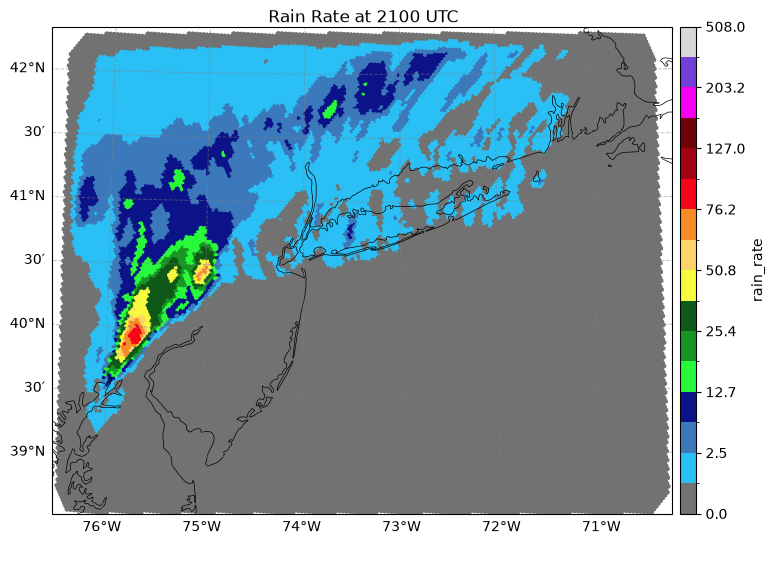

In [8]:
from earthcmap import escmap

cmap, norm = escmap("nwps_qpe", units="mm")

mpasd.show(
    dta,
    var_name="rain_rate",
    time_index=8,
    figsize=(8,8),
    cmap=cmap,
    norm=norm,
)
plt.title(
    "Rain Rate at 2100 UTC",
    pad=30,
    x=0.57 #shifts the title to the center of the plot
)

Rain rate is used to identify the location and intensity of the heaviest precipitation associated with the remnants of Hurricane Ida.

###  Reflectivity

Text(0.57, 1.0, 'Maximum 10-cm Reflectivity at 2100 UTC')

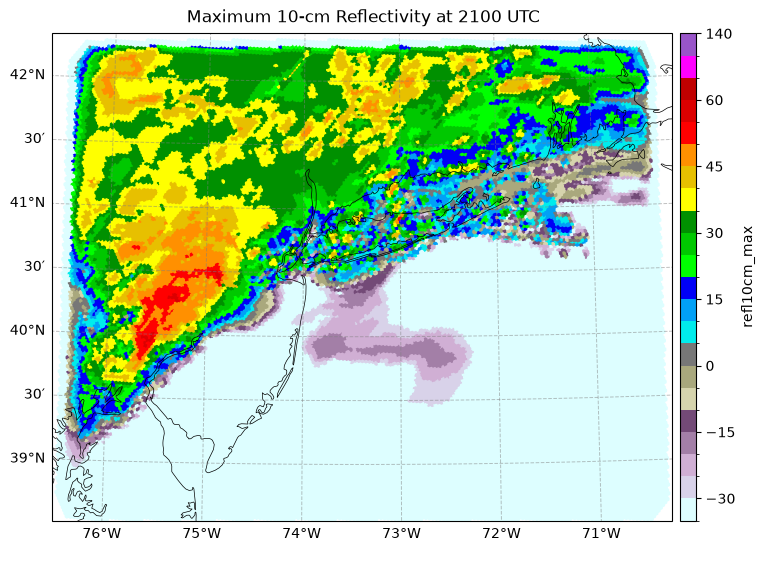

In [9]:
cmap, norm = escmap("mrms_cref")

mpasd.show(
    dta,
    var_name="refl10cm_max",
    time_index=8,
    figsize=(8,8),
    cmap=cmap,
    norm=norm,
)
plt.title(
    "Maximum 10-cm Reflectivity at 2100 UTC",
    pad=30,
    x=0.57
)

Simulated maximum reflectivity highlights regions of organized precipitation and convective structures during the event.

### Outgoing Longwave Radiation

Text(0.73, 1.0, 'OLR at 2100 UTC')

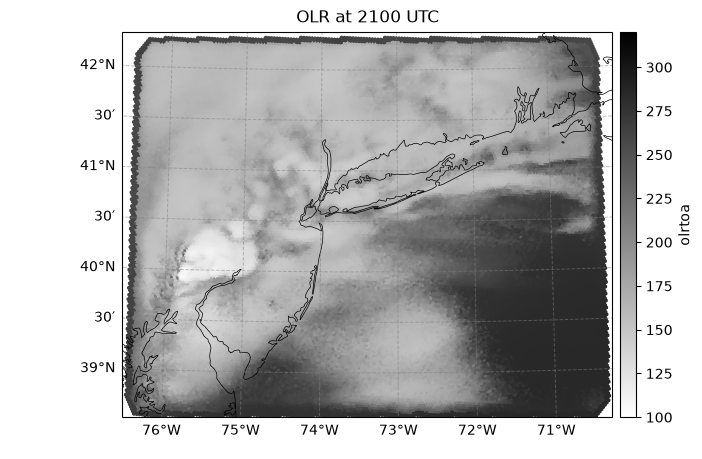

In [20]:
# importing for colormap usage
import matplotlib.colors as colors
cmap = plt.get_cmap("gray_r")
norm = colors.Normalize(vmin=100, vmax=320)\

mpasd.show(
    dta,
    var_name="olrtoa",
    time_index=8,
    figsize=(8, 5),
    cmap=cmap,
    norm=norm,
)
plt.title(
    "OLR at 2100 UTC",
    pad=30,
    x=0.73
)

Outgoing longwave radiation (OLR) provides information about cloud-top characteristics, with lower values generally associated with deeper convection and colder cloud tops.

## Evolution of Rainfall During Hurricane Ida

To better understand the temporal evolution of the event, we create an animation of simulated rain rate from 13 UTC 1 September through 12 UTC 2 September 2021. This animation highlights the development, intensification, and movement of precipitation associated with the remnants of Hurricane Ida.

### Install Imageio to make a gif

In [11]:
!pip install imageio

### Plotting 3 time frames before peak, during peak and after peak

In [12]:
# NWS Color QPE colormaps
cmap, norm = escmap("nwps_qpe", units="mm")

# Select representative times showing the evolution of rainfall: before peak intensity, during peak intensity, and after the event begins to weaken.
times = [6, 8, 15]

for idx in times:
    mpasd.show(
        dta,
        var_name="rain_rate",
        time_index=idx,
        figsize=(5,5),
        cmap=cmap,
        norm=norm,
    )

     # Add timestamp to each frame
    timestamp = pd.to_datetime(dta.time.values[idx])
    timestr = timestamp.strftime("%d %b %Y, %H:%M UTC")

    ax = plt.gca()
    plt.title(
        f"\n{timestr}",
        pad=40,
        x=0.61
    )

    plt.savefig(
        f"rain_rate_{idx:02d}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

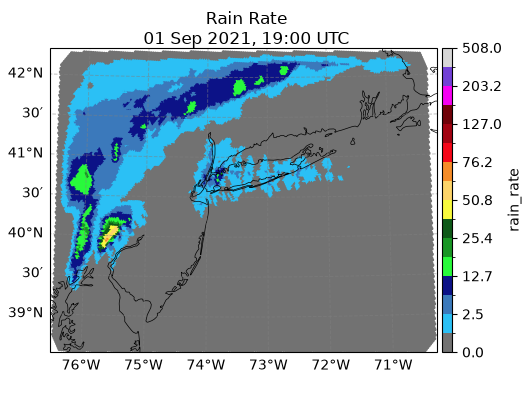

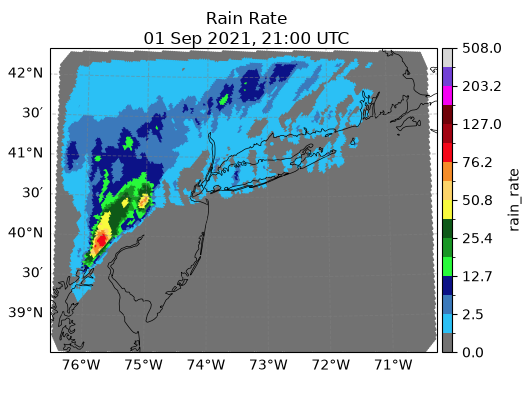

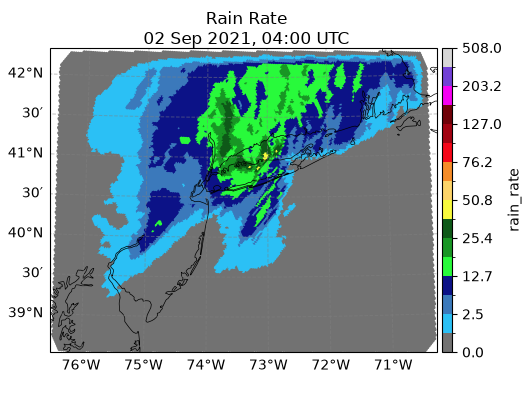

In [13]:
# NWS map colors
cmap, norm = escmap("nwps_qpe", units="mm")

times = [6, 8, 15]

for idx in times:
    mpasd.show(
        dta,
        var_name="rain_rate",
        time_index=idx,
        figsize=(5, 5),
        cmap=cmap,
        norm=norm,
    )

    timestamp = pd.to_datetime(dta.time.values[idx])
    timestr = timestamp.strftime("%d %b %Y, %H:%M UTC")

    ax = plt.gca()
    ax.set_title(
        f"Rain Rate\n{timestr}",
        pad=40,
        x=0.61
    )

    plt.show()

## Making all 24 time steps into a GIF

In [14]:
# NWS map colors
cmap, norm = escmap("nwps_qpe", units="mm")

# Save each hourly rain-rate map as an image

for idx in range(len(dta.time)):

    mpasd.show(
        dta,
        var_name="rain_rate",
        time_index=idx,
        figsize=(5, 5),
        cmap=cmap,
        norm=norm,
    )

    # Add timestamp to each frame
    timestamp = pd.to_datetime(dta.time.values[idx])
    timestr = timestamp.strftime("%d %b %Y, %H:%M UTC")

    plt.title(
        f"\n{timestr}",
        pad=40,
        x=0.61
    )

    plt.savefig(
        f"rain_rate_{idx:02d}.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

In [15]:
# Making the GIF
from PIL import Image

files = [f"rain_rate_{i:02d}.png" for i in range(len(dta.time))]

frames = [Image.open(f).convert("RGB") for f in files]

frames[0].save(
    "ida_rainfall_evolution_24hr.gif",
    save_all=True,
    append_images=frames[1:],
    duration=500,
    loop=0
)

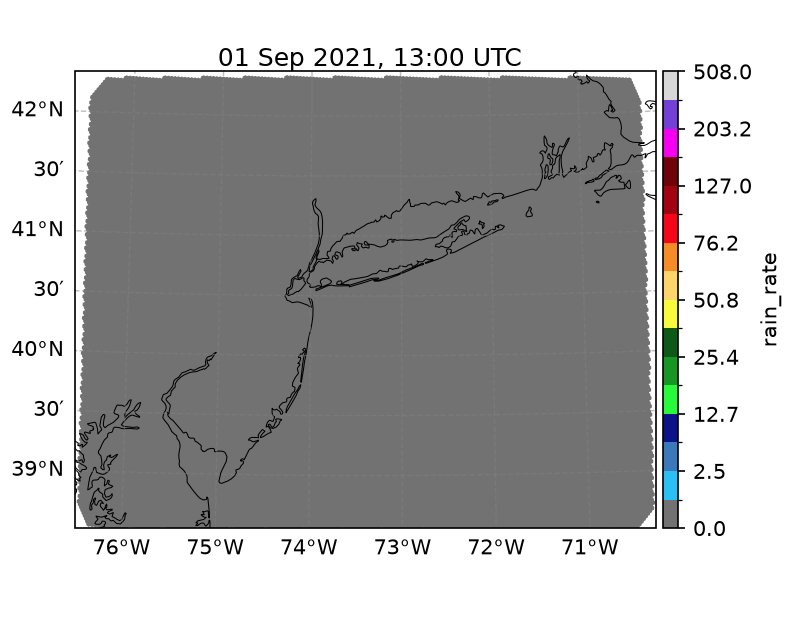

In [16]:
# displaying the GIF
from IPython.display import Image as IPImage
IPImage(filename="ida_rainfall_evolution_24hr.gif")

Figure: Animation of MPAS-A simulated rain rate during the remnants of Hurricane Ida from 13 UTC 1 September to 12 UTC 2 September 2021. The animation highlights the evolution and movement of heavy precipitation bands across the northeastern United States, with peak rainfall occurring during the evening hours of 1 September.